# Tasks:

1. Modify history experience for user via history manager (Redis);
2. Add state memory (Postgre);
3. Add LangFlow (to check model working);

# Import libs

In [14]:
import json
import time
import hashlib
from typing import TypedDict, List, Optional
from langchain_core.prompts import ChatPromptTemplate
from langchain_redis import RedisSemanticCache
from langchain_community.embeddings.yandex import YandexGPTEmbeddings
import redis
from langchain_core.outputs import Generation
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
import asyncio
from abc import ABC

# Работаем с секретами
from dotenv import load_dotenv
import os

# Define global args

In [2]:
load_dotenv("../../.env")

True

In [3]:
openai_api_key=os.getenv("API_KEY")
FOLDER_ID = os.getenv("FOLDER_ID")
openai_api_base="https://llm.api.cloud.yandex.net/v1"
model=f"gpt://{FOLDER_ID}/yandexgpt"
redis_url = "redis://127.0.0.1:6379"  # ваш Redis URL

In [4]:
class AgentState(TypedDict):
    user_history: List[str]
    text: str
    is_valid: bool
    validation_errors: List[str]
    answers: List[str]
    parts: List[str]
    final_answer: str
    additional_documents: List[str]

# Define Semantic Cache logic

In [5]:
embeddings = YandexGPTEmbeddings(
    folder_id=os.getenv("FOLDER_ID"),
    iam_token=os.getenv("API_KEY") 
)

In [6]:
semantic_cache = RedisSemanticCache(
    redis_url=redis_url,
    embeddings=embeddings,
    distance_threshold=0.1,
    ttl=3600
)

# Define LLM

In [7]:
llm = ChatOpenAI(
    model=model,
    temperature=0,
    openai_api_base=openai_api_base,
    openai_api_key=openai_api_key, 
)

# Define WorkFlow for Agent

In [8]:
class ValidationAgent:
    def __init__(self, llm, cache, prompt_dir="../../prompts", s3_info: Optional[dict] = None):
        self.llm = llm
        self.semantic_cache = cache
        self.s3_info = s3_info or {}
        self.prompts = {
            "validate": self.load_prompt(f"{prompt_dir}/validate_text.txt", how="local"),
            "decompose": self.load_prompt(f"{prompt_dir}/decompose_question.txt", how="local"),
            "answer_part": self.load_prompt(f"{prompt_dir}/answer_part.txt", how="local"),
            "collect_final": self.load_prompt(f"{prompt_dir}/summary_results.txt", how="local"),
            "validate_final": self.load_prompt(f"{prompt_dir}/validate_text.txt", how="local")
        }

    @staticmethod
    def load_prompt(path: str, how: str = "local") -> str:
        if how == "local":
            with open(path, "r", encoding="utf-8") as f:
                return f.read()
        elif how == "s3":
            s3_params = ValidationAgent._get_s3_params()
            with boto3.client('s3') as s3:
                obj = s3.get_object(Bucket=s3_params["bucket"], Key=s3_params["key"])
                return obj['Body'].read().decode('utf-8')
        else:
            raise NotImplementedError(f"Unknown source: {how}")

    @staticmethod
    def _get_s3_params():
        # Исправлено: s3_params → динамическое получение
        return {"bucket": "your-bucket", "key": path.split('/')[-1]}  # Адаптируйте под ваши параметры

    def _get_cache_key(self, text: str, namespace: str) -> str:
        """Генерирует стабильный хэш для Redis ключа"""
        if len(text) < int(os.getenv("REDIS_LIMITED_QUESTION_LENGTH", 1400)):
            text_hash = hashlib.md5(text.encode('utf-8')).hexdigest()
            return f"{namespace}:{text_hash}"
        return None

    def _cache_question_answer(self, question: str, namespace_name: str):
        """Безопасное кэширование с json.loads()"""
        cache_key = self._get_cache_key(question, namespace_name)
        if not cache_key:
            return None
            
        try:
            semantic = self.semantic_cache.lookup(cache_key, namespace_name)
            if semantic:
                return json.loads(semantic[0].text)["answer"]
        except (json.JSONDecodeError, KeyError, IndexError):
            pass
        return None

    def _cache_parts(self, question: str, parts: list, namespace_name: str):
        """Кэширование частей разбиения"""
        cache_key = self._get_cache_key(question, namespace_name)
        if cache_key:
            self.semantic_cache.update(
                cache_key, namespace_name, 
                [Generation(text=json.dumps({"parts": parts}))]
            )

    def validate_text(self, state: AgentState) -> AgentState:
        question = state["text"]
        cached_answer = self._cache_question_answer(question, "validate")
        
        if cached_answer:
            response = cached_answer
            is_valid = "да" in response.lower()
        else:
            prompt = ChatPromptTemplate.from_template(self.prompts["validate"])
            chain = prompt | self.llm
            response = chain.invoke({"text": state["text"]}).content.strip().lower()
            is_valid = "да" in response
            
            # Кэшируем только при ошибке валидации
            cache_key = self._get_cache_key(question, "validate")
            if cache_key:
                self.semantic_cache.update(
                    cache_key, "validate", 
                    [Generation(text=json.dumps({"answer": response}))]
                )
        
        if is_valid:
            state["is_valid"] = True
            state["validation_errors"] = []
        else:
            state["is_valid"] = False
            state["final_answer"] = response
            msg = response.replace("нет", "").strip()
            state["validation_errors"] = [msg] if msg else ["Не прошёл валидацию"]
            
        return state

    def decompose_question(self, state: AgentState) -> AgentState:
        question = state["text"]
        cached_data = self._cache_question_answer(question, "decompose")
        
        if cached_data:
            try:
                cached_parts = json.loads(cached_data).get("parts", [])
                state["parts"] = cached_parts
            except (json.JSONDecodeError, KeyError):
                state["parts"] = []
        else:
            prompt = ChatPromptTemplate.from_template(self.prompts["decompose"])
            chain = prompt | self.llm
            response = chain.invoke({
                "user_question": question,
                "user_history": state["user_history"]
            }).content.strip()
            
            parts = [line.strip("- ").strip() for line in response.split("\n") if line.strip()]
            state["parts"] = parts
            
            self._cache_parts(question, parts, "decompose")
        return state

    async def answer_parts_async(self, state: AgentState, max_concurrent: int = 8) -> AgentState:
        state["answers"] = []
        semaphore = asyncio.Semaphore(max_concurrent)
        prompt = ChatPromptTemplate.from_template(self.prompts["answer_part"])
        chain = prompt | self.llm
    
        async def call_llm(part: str, state: AgentState) -> str:
            cached_answer = self._cache_question_answer(part, "answer_part")
            if cached_answer:
                return cached_answer
            
            async with semaphore:
                result = await chain.ainvoke({
                    "task_question": part,
                    "additional_documents": state["additional_documents"]
                })
                answer = result.content.strip()
                
                cache_key = self._get_cache_key(part, "answer_part")
                if cache_key:
                    self.semantic_cache.update(
                        cache_key, "answer_part", 
                        [Generation(text=json.dumps({"answer": answer}))]
                    )
                return answer
    
        if state.get("parts"):
            tasks = [asyncio.create_task(call_llm(part, state)) for part in state["parts"]]
            results = await asyncio.gather(*tasks, return_exceptions=True)
            state["answers"] = [str(r) if not isinstance(r, Exception) else f"Error: {r}" for r in results]
        
        return state

    def collect_final_answer(self, state: AgentState) -> AgentState:
        question = state["text"]
        cached_final = self._cache_question_answer(question, "collect_final")
        
        if cached_final:
            state["final_answer"] = cached_final
        else:
            if state.get("answers"):
                answers_text = "\n".join(f"{i + 1}. {ans}" for i, ans in enumerate(state["answers"]) if ans)
                prompt = ChatPromptTemplate.from_template(self.prompts["collect_final"])
                chain = prompt | self.llm
                response = chain.invoke({
                    "task_responses": answers_text,
                    "user_history": state["user_history"],
                    "original_question": question
                }).content.strip()
                state["final_answer"] = response
                
                cache_key = self._get_cache_key(question, "collect_final")
                if cache_key:
                    self.semantic_cache.update(
                        cache_key, "collect_final", 
                        [Generation(text=json.dumps({"answer": response}))]
                    )
            else:
                state["final_answer"] = "Нет данных для итогового ответа."
        return state

    def validate_final_answer(self, state: AgentState) -> AgentState:
        final_answer = state.get("final_answer", "")
        cache_key = self._get_cache_key(final_answer[:1000], "validate_final")
        
        if cache_key:
            cached_validation = self._cache_question_answer(final_answer[:1000], "validate_final")
            if cached_validation:
                state["summary_is_complete"] = "да" in cached_validation.lower()
                return state
        
        prompt = ChatPromptTemplate.from_template(self.prompts["validate_final"])
        chain = prompt | self.llm
        output = chain.invoke({"text": final_answer}).content.strip().lower()
        state["summary_is_complete"] = "да" in output
        
        if cache_key:
            self.semantic_cache.update(
                cache_key, "validate_final", 
                [Generation(text=json.dumps({"answer": output}))]
            )
        return state

    def reject_stub(self, state: AgentState) -> AgentState:
        state["final_answer"] = "Текст не соответствует тематике вопросов для диалога с чат-ботом. Повторите свой вопрос еще раз."
        state["is_valid"] = False
        return state


In [9]:
# Ветка выбора: если валидация пройдена — генерация ответа; иначе — stub
def route(state: AgentState):
    return "decompose_question" if state["is_valid"] else "reject_stub"

In [10]:
agent = ValidationAgent(llm, semantic_cache)

# Build Graph

In [11]:
builder = StateGraph(AgentState, is_async=True)
builder.add_node("validate", agent.validate_text)
builder.add_node("decompose_question", agent.decompose_question)
builder.add_node("answer_parts_async", agent.answer_parts_async)
builder.add_node("reject_stub", agent.reject_stub)
builder.add_node("collect_final_answer", agent.collect_final_answer)
builder.add_node("validate_final_answer", agent.validate_final_answer)

builder.set_entry_point("validate")

def route(state: AgentState):
    return "decompose_question" if state["is_valid"] else "reject_stub"

builder.add_conditional_edges("validate", route, {
    "decompose_question": "decompose_question",
    "reject_stub": "reject_stub"
})

builder.add_edge("reject_stub", END)
builder.add_edge("decompose_question", "answer_parts_async")
builder.add_edge("answer_parts_async", "collect_final_answer")
builder.add_edge("collect_final_answer", "validate_final_answer")
builder.add_edge("validate_final_answer", END)

validation_agent = builder.compile()

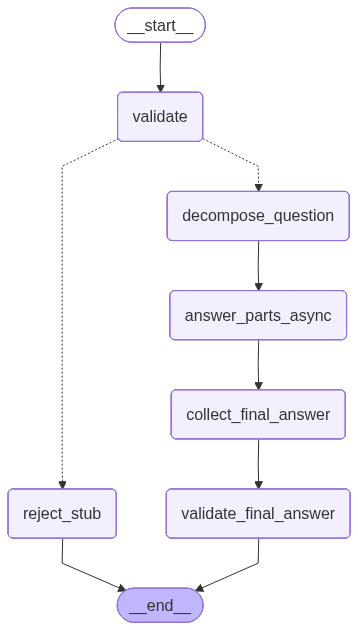

In [12]:
validation_agent

In [15]:
start_state = {
    "text": "Приветствую! Кто ты?",
    "is_valid": False,
    "validation_errors": [],
    "parts": [],
    "answers": [],
    "final_answer": "",
    "user_history": ["Привет Я Вася Пупкин! Из 6 цеха"],
    "additional_documents": ["Не получилось получить доступ к базе данных профкома"]
}

start = time.time()
result = await validation_agent.ainvoke(start_state)
end = time.time()

print(f"Время: {end-start:.3f} сек")
print(result["final_answer"])

Время: 3.350 сек
Здравствуйте! Я помогаю членам профсоюза разобраться в их правах и льготах. Если у вас есть вопросы, связанные с работой профсоюза, — просто напишите их, и я подскажу, что делать прямо сейчас.


In [17]:
result

{'user_history': ['Привет Я Вася Пупкин! Из 6 цеха'],
 'text': 'Приветствую! Кто ты?',
 'is_valid': True,
 'validation_errors': [],
 'answers': ['Я готов ответить на ваши вопросы, связанные с работой профсоюза. Чем могу помочь?',
  'Я профсоюзный юрист, готовый ответить на ваши вопросы по работе профсоюза.',
  'Я готов ответить на ваши вопросы, связанные с работой профсоюза. Чем могу помочь?'],
 'parts': ['<ЗАДАЧИ>', 'Кто я и какую роль выполняю?', '</ЗАДАЧИ>'],
 'final_answer': 'Здравствуйте! Я помогаю членам профсоюза разобраться в их правах и льготах. Если у вас есть вопросы, связанные с работой профсоюза, — просто напишите их, и я подскажу, что делать прямо сейчас.',
 'additional_documents': ['Не получилось получить доступ к базе данных профкома']}